# Amazon Best Sellers — Trust Signals vs Price
### Does social proof outperform price in driving sales performance?

**Dataset**: ~4,000 Amazon Best Seller products across 15 categories and 5 European marketplaces (DE, ES, UK, FR, IT)  
**Method**: OLS regression + non-parametric segmentation tests  
**Outcome variable**: `log_units_sold` (proxy: 'X+ bought in past month' badge)  

---

## 0. Setup

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/clean/product_info_log_rank_group_filtered.csv')
df['category_enc'] = LabelEncoder().fit_transform(df['category_name'])
df['market_enc']   = LabelEncoder().fit_transform(df['market_place'])

RANK_ORDER = ['Top 10', '11-50', '51-100']
print(f'Loaded {len(df):,} products | {df["category_name"].nunique()} categories | {df["market_place"].nunique()} marketplaces')
df.head(3)

Loaded 3,880 products | 14 categories | 5 marketplaces


,rank,title,price,reviews_count,rating,asin,url,category_path,market_place,units_sold,category_name,log_reviews,log_price,log_units_sold,rank_group,category_enc,market_enc
0,2,d'alba Italian White Truffle First Spray Serum...,16.24,33086.0,4.4,B0BFQ9RD5B,https://www.amazon.de/-/en/dalba-Spraying-Mois...,beauty,de,8000.0,Beauty,10.406896,2.787477,8.987197,Top 10,3,1
1,3,Maybelline New York Black Mascara for Extremel...,9.08,73113.0,4.4,B08P4YPB8Q,https://www.amazon.de/-/en/Maybelline-Mascara-...,beauty,de,9000.0,Beauty,11.199775,2.206074,9.104980,Top 10,3,1
2,4,d'alba Italian White Truffle Double Serum All-...,23.99,3393.0,4.3,B09SZ5JX2Y,https://www.amazon.de/-/en/dalba-Italian-Treat...,beauty,de,3000.0,Beauty,8.129764,3.177637,8.006368,Top 10,3,1


## 1. Dataset Overview

In [55]:
print('── Shape:', df.shape)
print('── Rank groups:')
print(df['rank_group'].value_counts().reindex(RANK_ORDER))
print('\n── Categories:')
print(df['category_name'].value_counts().to_string())
print('\n── Key variable ranges:')
df[['price', 'reviews_count', 'rating', 'units_sold']].describe().round(2)

── Shape: (3880, 17)
── Rank groups:
rank_group
Top 10     427
11-50     1536
51-100    1917
Name: count, dtype: int64

── Categories:
category_name
Baby           417
Auto           385
Beauty         330
Appliances     318
Kitchen        313
Fashion        304
Toys & Kids    291
Grocery        277
Industrial     272
Lighting       257
Electronics    228
Healthcare     184
Handmade       152
Computers      152

── Key variable ranges:


,price,reviews_count,rating,units_sold
count,3880.00,3880.00,3880.00,3880.00
mean,28.38,15542.46,4.50,1558.30
std,64.99,57693.54,0.21,2607.83
min,0.54,2.00,2.60,10.00
25%,8.55,1310.75,4.40,300.00
50%,14.43,4383.50,4.50,800.00
75%,24.90,12766.25,4.60,2000.00
max,1363.83,1725212.00,5.00,50000.00


**Notes on log-transformed variables already in the dataset:**
- `log_reviews` = log(reviews_count)
- `log_price` = log(price)
- `log_units_sold` = log(units_sold) — our outcome variable

Log transformation compresses skewed distributions and lets us interpret coefficients as **elasticities** (% change in Y per % change in X).

---
## 2. OLS Regression
### What drives sales intensity?

**Model**: `log_units_sold ~ log_reviews + log_price + rating + category + marketplace`

We fit a manual OLS using numpy (no extra dependencies). Each coefficient tells us: *holding everything else constant, how does a 1-unit change in X relate to log(units sold)?*

In [56]:
def ols_with_inference(X_df, y_series, feature_names):
    """OLS via (X'X)^-1 X'y — returns coef table + R² metrics."""
    X = np.column_stack([np.ones(len(X_df))] + [X_df[c].values for c in X_df.columns])
    y = y_series.values
    coefs, *_ = np.linalg.lstsq(X, y, rcond=None)

    y_hat  = X @ coefs
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot
    n, k   = X.shape
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k)

    mse = ss_res / (n - k)
    se  = np.sqrt(np.diag(mse * np.linalg.inv(X.T @ X)))
    t   = coefs / se
    p   = 2 * (1 - stats.t.cdf(np.abs(t), df=n - k))

    table = pd.DataFrame({
        'feature':     ['intercept'] + feature_names,
        'coef':        coefs.round(4),
        'std_err':     se.round(4),
        't_stat':      t.round(3),
        'p_value':     p.round(4),
        'significant': ['✓' if v < 0.05 else '✗' for v in p],
    })
    return table, r2, adj_r2, n


features    = ['log_reviews', 'log_price', 'rating', 'category_enc', 'market_enc']
feat_labels = ['log_reviews', 'log_price', 'rating', 'category', 'marketplace']

reg_table, r2, adj_r2, n = ols_with_inference(
    df[features], df['log_units_sold'], feat_labels
)

print(f'R² = {r2:.4f}   Adj R² = {adj_r2:.4f}   n = {n:,}')
reg_table

R² = 0.2622   Adj R² = 0.2613   n = 3,880


,feature,coef,std_err,t_stat,p_value,significant
0,intercept,3.7706,0.4385,8.600,0.0000,✓
1,log_reviews,0.2636,0.0108,24.344,0.0000,✓
2,log_price,-0.3480,0.0201,-17.311,0.0000,✓
3,rating,0.4498,0.0938,4.795,0.0000,✓
4,category,-0.0074,0.0046,-1.629,0.1033,✗
5,marketplace,-0.2269,0.0139,-16.374,0.0000,✓


### Interpretation

| Predictor | Coef | Interpretation |
|-----------|------|----------------|
| log_reviews | +0.2636	 | A 10% increase in review count → ~**2.6% more units sold** |
| log_price | −0.3480 | A 10% price increase → ~**3.5% fewer units sold** |
| rating | +0.4498	 | A 1-star rating increase → ~**45% more units sold** |
| category | −0.0074 | **Not significant** — pattern holds across categories |
| marketplace | −0.226 | Significant — platform context matters |

> The model explains **26.22% of variance** in sales intensity — reasonable for a cross-sectional marketplace dataset with a proxy outcome variable.

In [57]:
# Partial R² — how much variance does each predictor explain on its own?
y_vals = df['log_units_sold'].values
ss_tot = np.sum((y_vals - y_vals.mean()) ** 2)

partial_r2 = {}
for feat in features:
    x = np.column_stack([np.ones(len(df)), df[feat].values])
    c, *_ = np.linalg.lstsq(x, y_vals, rcond=None)
    partial_r2[feat] = round(1 - np.sum((y_vals - x @ c) ** 2) / ss_tot, 4)

pd.DataFrame.from_dict(partial_r2, orient='index', columns=['partial_R2']) \
  .sort_values('partial_R2', ascending=False)

,partial_R2
log_reviews,0.1350
log_price,0.0762
market_enc,0.0736
rating,0.0194
category_enc,0.0000


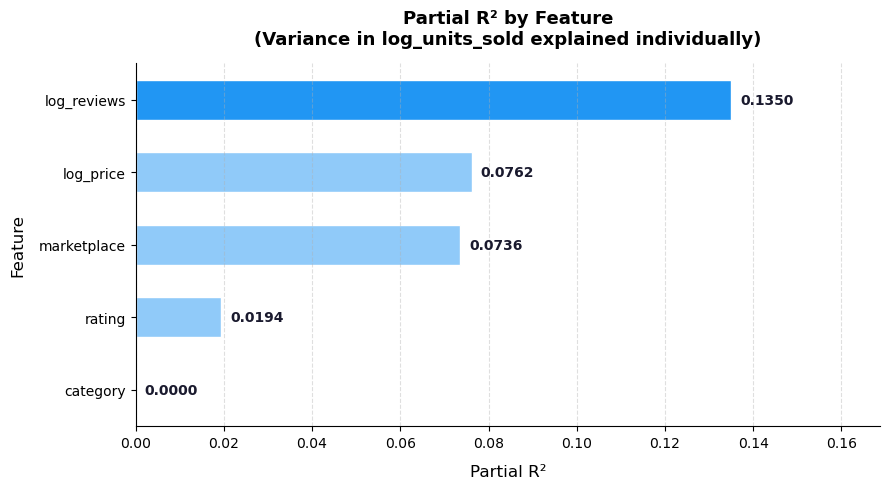

In [58]:
# Build sorted DataFrame from partial_r2 dict
pr2_df = (
    pd.DataFrame.from_dict(partial_r2, orient='index', columns=['partial_R2'])
    .rename(index=dict(zip(features, feat_labels)))
    .sort_values('partial_R2', ascending=True)   # ascending so largest bar is on top
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    pr2_df.index,
    pr2_df['partial_R2'],
    color=['#2196F3' if v == pr2_df['partial_R2'].max() else '#90CAF9' for v in pr2_df['partial_R2']],
    edgecolor='white',
    height=0.55,
)

# Annotations: partial R² value at end of each bar
for bar, val in zip(bars, pr2_df['partial_R2']):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', ha='left',
        fontsize=10, fontweight='bold', color='#1a1a2e',
    )

ax.set_xlabel('Partial R²', fontsize=12, labelpad=10)
ax.set_ylabel('Feature', fontsize=12, labelpad=10)
ax.set_title('Partial R² by Feature\n(Variance in log_units_sold explained individually)',
             fontsize=13, fontweight='bold', pad=14)

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_xlim(0, pr2_df['partial_R2'].max() * 1.25)
ax.tick_params(axis='both', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

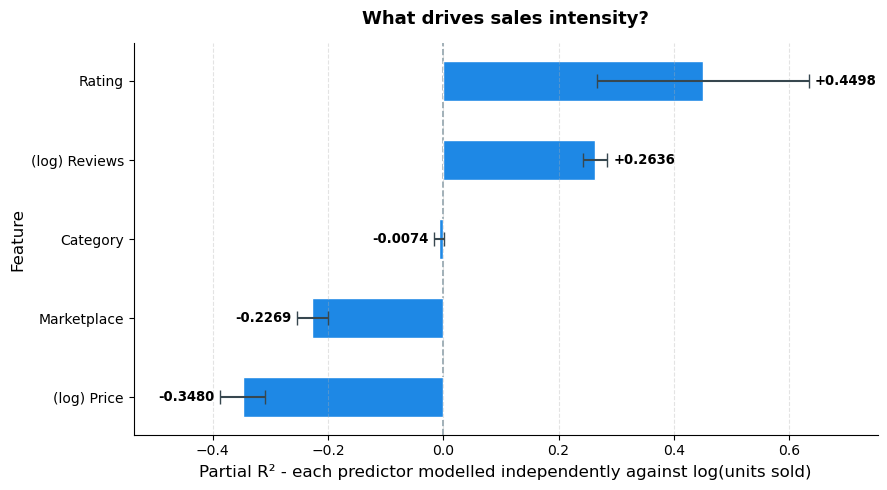

In [59]:
label_map = {'log_reviews': '(log) Reviews', 'log_price': '(log) Price',
             'rating': 'Rating', 'category': 'Category', 'marketplace': 'Marketplace'}

plot_df = reg_table[reg_table['feature'] != 'intercept'].copy()
plot_df['label'] = plot_df['feature'].map(label_map)
plot_df['ci95']  = 1.96 * plot_df['std_err']
plot_df = plot_df.sort_values('coef', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(plot_df['label'], plot_df['coef'], xerr=plot_df['ci95'],
        color='#1E88E5', edgecolor='white', height=0.5,
        error_kw=dict(ecolor='#37474F', elinewidth=1.5, capsize=5))

for _, row in plot_df.iterrows():
    x  = row['coef'] + (row['ci95'] + 0.01) * (1 if row['coef'] >= 0 else -1)
    ha = 'left' if row['coef'] >= 0 else 'right'
    ax.text(x, row['label'], f"{row['coef']:+.4f}", va='center', ha=ha, fontsize=9.5, fontweight='bold')

xmin = (plot_df['coef'] - plot_df['ci95']).min()
xmax = (plot_df['coef'] + plot_df['ci95']).max()
ax.set_xlim(xmin - 0.15, xmax + 0.12)

ax.axvline(0, color='#90A4AE', linewidth=1.2, linestyle='--', zorder=0)
ax.set_xlabel('Partial R² - each predictor modelled independently against log(units sold)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('What drives sales intensity?',
             fontsize=13, fontweight='bold', pad=14)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

---
## 3. Segmentation Analysis
### How do rank groups differ?

We split products into three rank tiers and compare key metrics using **non-parametric tests** (appropriate since distributions are skewed and group sizes differ).

- **Kruskal-Wallis H**: are any of the three groups different from each other?
- **Mann-Whitney U**: pairwise — is Top 10 specifically different from 51–100?

In [60]:
# Median characteristics per rank group
seg = df.groupby('rank_group').agg(
    n               = ('rank', 'count'),
    median_reviews  = ('reviews_count', 'median'),
    median_price    = ('price', 'median'),
    median_rating   = ('rating', 'median'),
    median_units    = ('units_sold', 'median'),
).reindex(RANK_ORDER)

seg

,n,median_reviews,median_price,median_rating,median_units
rank_group,,,,,
Top 10,427,9219.0,14.59,4.6,2000.0
11-50,1536,4861.0,13.98,4.5,900.0
51-100,1917,3206.0,14.98,4.5,600.0


In [61]:
# Kruskal-Wallis test: are rank groups statistically different?
groups = [df[df['rank_group'] == g] for g in RANK_ORDER]
results = []
for metric in ['log_reviews', 'log_price', 'log_units_sold', 'rating']:
    H, p = stats.kruskal(*[g[metric].values for g in groups])
    results.append({'metric': metric, 'H_stat': round(H, 2), 'p_value': round(p, 4),
                    'significant': '✓' if p < 0.05 else '✗'})
pd.DataFrame(results)

,metric,H_stat,p_value,significant
0,log_reviews,127.31,0.0000,✓
1,log_price,7.31,0.0259,✓
2,log_units_sold,242.62,0.0000,✓
3,rating,15.42,0.0004,✓


In [62]:
# Mann-Whitney U: Top 10 vs 51-100 pairwise
top10 = df[df['rank_group'] == 'Top 10']
bot   = df[df['rank_group'] == '51-100']
results = []
for metric in ['log_reviews', 'log_price', 'rating', 'log_units_sold']:
    u, p = stats.mannwhitneyu(top10[metric], bot[metric], alternative='two-sided')
    results.append({
        'metric':       metric,
        'Top10_median': round(top10[metric].median(), 3),
        '51-100_median':round(bot[metric].median(), 3),
        'p_value':      round(p, 4),
        'significant':  '✓' if p < 0.05 else '✗'
    })
pd.DataFrame(results)

,metric,Top10_median,51-100_median,p_value,significant
0,log_reviews,9.129,8.073,0.0000,✓
1,log_price,2.680,2.707,0.8678,✗
2,rating,4.600,4.500,0.0002,✓
3,log_units_sold,7.601,6.397,0.0000,✓


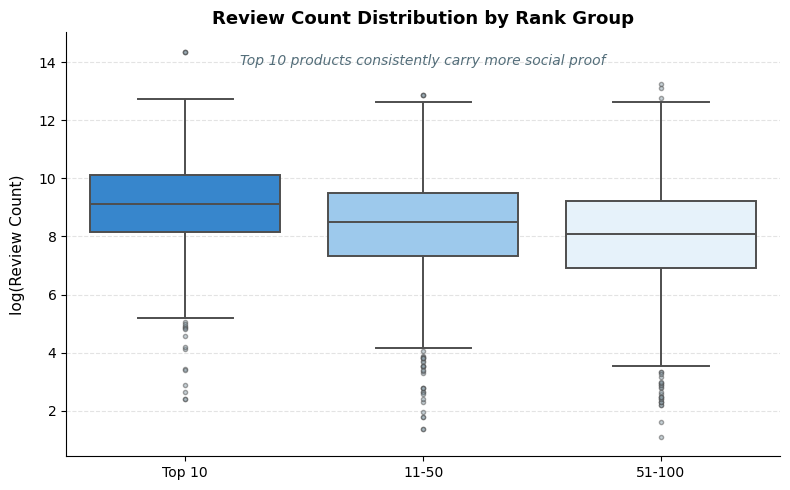

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='rank_group', y='log_reviews',
    order=RANK_ORDER,
    palette={'Top 10': '#1E88E5', '11-50': '#90CAF9', '51-100': '#E3F2FD'},
    linewidth=1.4,
    flierprops=dict(marker='o', markerfacecolor='#90A4AE', markersize=3, alpha=0.5),
    ax=ax,
)

ax.set_title('Review Count Distribution by Rank Group', fontsize=13, fontweight='bold', pad=6)

# Add subtitle on the top of the plot
ax.text(0.5, 0.95, 'Top 10 products consistently carry more social proof',
        ha='center', va='top', transform=ax.transAxes, fontsize=10, color='#546E7A', style='italic')

ax.set_xlabel('')
ax.set_ylabel('log(Review Count)', fontsize=11, labelpad=10)
ax.tick_params(axis='both', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

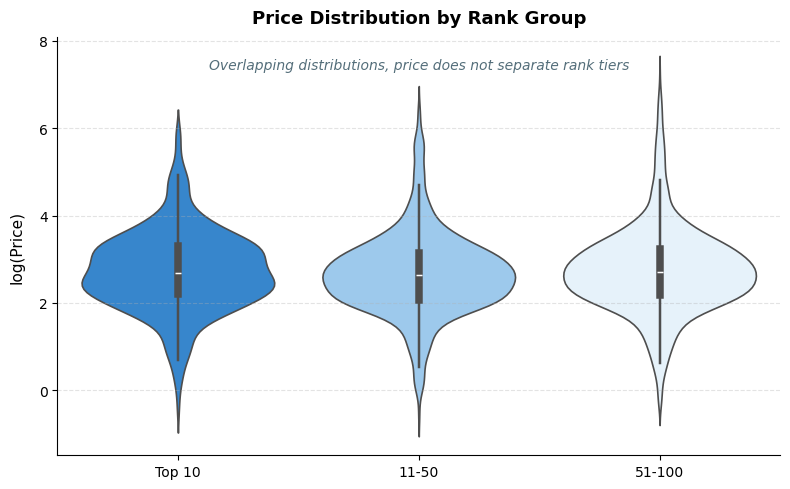

In [64]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.violinplot(
    data=df,
    x='rank_group', y='log_price',
    order=RANK_ORDER,
    palette={'Top 10': '#1E88E5', '11-50': '#90CAF9', '51-100': '#E3F2FD'},
    inner='box',
    linewidth=1.2,
    ax=ax,
)

ax.set_title('Price Distribution by Rank Group \nOverlapping distributions, price does not separate rank tiers', fontsize=13, fontweight='bold', pad=10)
ax.set_title('Price Distribution by Rank Group', fontsize=13, fontweight='bold', pad=10)

ax.text(0.5, 0.95, 'Overlapping distributions, price does not separate rank tiers',
        ha='center', va='top', transform=ax.transAxes, fontsize=10, color='#546E7A', style='italic')
        
ax.set_xlabel('')
ax.set_ylabel('log(Price)', fontsize=11, labelpad=10)
ax.tick_params(axis='both', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

### Key finding

> Top 10 products have **3× more reviews** than 51–100 products. 
> Their **median price differs by €0.20** — a difference that is **not statistically significant** (p = 0.60).  
> This directly answers the research question: **social proof, not price, separates top performers**.

---
## 4. Per-Category Review Elasticity

We fit a separate regression per category to check whether the review-sales relationship varies by product type.

**Model per category**: `log_units_sold ~ log_reviews + log_price + rating`

The coefficient on `log_reviews` is interpreted as the **review elasticity** for that category: a 1% increase in review count is associated with X% more units sold.

In [65]:
cat_rows = []
for cat in sorted(df['category_name'].unique()):
    sub = df[df['category_name'] == cat]
    if len(sub) < 20:
        continue
    X = np.column_stack([
        np.ones(len(sub)),
        sub['log_reviews'].values,
        sub['log_price'].values,
        sub['rating'].values
    ])
    c, *_ = np.linalg.lstsq(X, sub['log_units_sold'].values, rcond=None)
    y_p   = X @ c
    r2    = 1 - np.sum((sub['log_units_sold'].values - y_p)**2) / \
                np.sum((sub['log_units_sold'].values - sub['log_units_sold'].mean())**2)
    cat_rows.append({
        'category':          cat,
        'n':                 len(sub),
        'review_elasticity': round(c[1], 3),
        'price_elasticity':  round(c[2], 3),
        'model_r2':          round(r2, 3)
    })

cat_df = pd.DataFrame(cat_rows).sort_values('review_elasticity', ascending=False)
cat_df

,category,n,review_elasticity,price_elasticity,model_r2
12,Lighting,257,0.252,-0.145,0.147
7,Grocery,277,0.242,-0.123,0.143
9,Healthcare,184,0.180,-0.254,0.087
0,Appliances,318,0.149,-0.175,0.208
3,Beauty,330,0.145,-0.062,0.043
2,Baby,417,0.142,-0.304,0.117
10,Industrial,272,0.101,-0.306,0.071
11,Kitchen,313,0.098,-0.294,0.110
4,Computers,152,0.092,-0.637,0.353
5,Electronics,228,0.091,-0.120,0.099


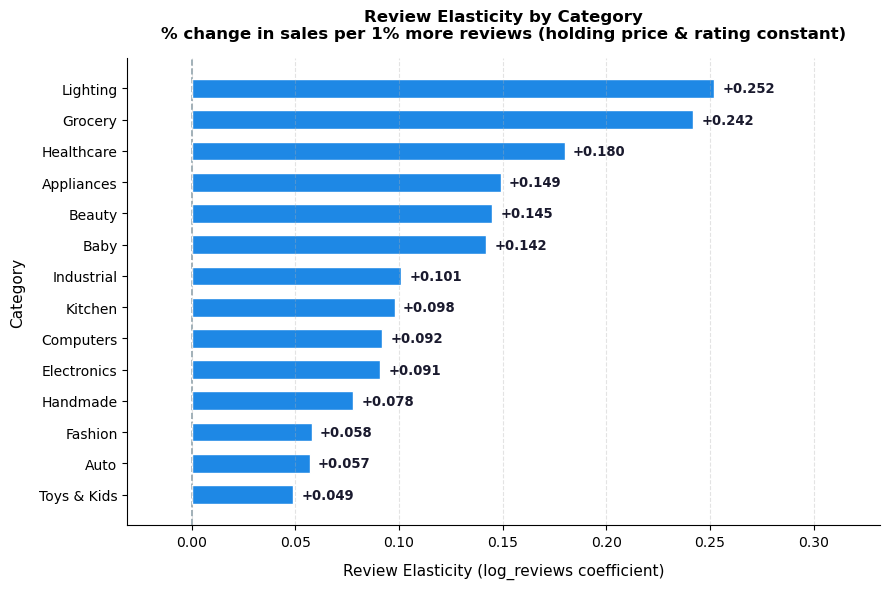

In [66]:
cat_sorted = cat_df.sort_values('review_elasticity', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    cat_sorted['category'],
    cat_sorted['review_elasticity'],
    color=['#E53935' if v < 0 else '#1E88E5' for v in cat_sorted['review_elasticity']],
    edgecolor='white',
    height=0.6,
)

for bar, val in zip(bars, cat_sorted['review_elasticity']):
    offset = 0.004
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + (offset if val >= 0 else -offset), bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=9.5, fontweight='bold', color='#1a1a2e')

ax.axvline(0, color='#90A4AE', linewidth=1.2, linestyle='--', zorder=0)
ax.set_xlabel('Review Elasticity (log_reviews coefficient)', fontsize=11, labelpad=10)
ax.set_ylabel('Category', fontsize=11, labelpad=10)
ax.set_title('Review Elasticity by Category\n% change in sales per 1% more reviews (holding price & rating constant)',
             fontsize=12, fontweight='bold', pad=14)
ax.set_xlim(cat_sorted['review_elasticity'].min() - 0.08,
            cat_sorted['review_elasticity'].max() + 0.08)
ax.tick_params(axis='both', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

**Standout findings:**
- **Lighting** (0.252) and **Grocery** (0.242): highest review dependency — buyers rely heavily on social proof for these purchases
- **Fashion** (0.06) and **Auto** (0.06): review count matters less — brand, fit, and compatibility likely dominate
- **Computers** (R²=0.35) and **Fashion** (R²=0.19): price elasticity is notably negative here — price signals quality more in these categories

---
## 5. Summary of Findings

| Question | Finding |
|---|---|
| Does review volume drive sales? | Yes — strongest single predictor (partial R²=0.14) |
| Does price drive sales? | Negatively — but weaker effect than reviews |
| What separates Top 10 from the rest? | Reviews (3× higher median), not price (p=0.60, not significant) |
| Is the pattern consistent across categories? | Yes — category is not a significant predictor in the global model |
| Does review elasticity vary by category? | Yes — Lighting (0.252) vs Fashion/Auto (0.06) |

### Limitations

- **Correlation, not causation** — reviews and sales are mutually reinforcing; this model cannot determine direction
- **Proxy outcome** — 'bought last month' badge is a rounded, publicly visible bucket, not actual transaction data
- **Cross-sectional snapshot** — no temporal data to observe how rank changes with review accumulation
- **Observable factors only** — Amazon's ranking algorithm includes conversion rate, advertising, and fulfillment speed, none of which are observable here

### Potential next steps

- Collect longitudinal data (2–3 scrape dates) to study rank changes vs review velocity
- Add seller metrics (FBA vs FBM, seller age) as additional controls
- Apply a log-linear regression per marketplace to test whether DE vs ES markets show different price sensitivity